In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# 2. Tentukan Path Folder (Ganti 'NamaFolder' dengan nama folder kamu di Drive)
path_folder = '/content/drive/MyDrive/Belajar Scrapping/SCrapping_Detik.com/Data_scrapping/Data/'

files = [
    'hasil_preprocessing_lowercase.csv'
]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv(path_folder + files[0])
df

,Headline,Tanggal,Link,Isi Berita,data_clean
0,7 Capaian Polda Metro Sepanjang 2025,2026-01-01,https://news.detik.com/berita/d-8287136/7-capa...,Kepolisian Daerah (Polda) Metro Jaya menutup t...,kepolisian daerah polda metro jaya menutup tah...
1,Gibran Angkat Bicara soal Pembangunan IKN,2026-01-01,https://finance.detik.com/infrastruktur/d-8287...,Pembangunan Ibu Kota Nusantara (IKN) di Kalima...,pembangunan ibu kota nusantara ikn di kalimant...
2,"Kunjungan Wisman ke Bali Melejit Saat Nataru, ...",2026-01-01,https://www.detik.com/bali/wisata/d-8287190/ku...,Kunjungan wisatawan mancanegara ke Bali meleji...,kunjungan wisatawan mancanegara ke bali meleji...
3,"China Tegaskan Niat Reunifikasi, Taiwan Bertek...",2026-01-02,https://news.detik.com/dw/d-8288417/china-tega...,"Dalam pidato Tahun Baru, Presiden Taiwan Lai C...",dalam pidato tahun baru presiden taiwan lai ch...
4,Kehadiran Negara dan Efektivitas Penanganan Be...,2026-01-02,https://news.detik.com/kolom/d-8288430/kehadir...,Kehadiran Presiden Prabowo Subianto di lokasi ...,kehadiran presiden prabowo subianto di lokasi ...
...,...,...,...,...,...
1130,"Sejarah Hari Buruh, dari Tragedi Haymarket hin...",2026-04-30,https://www.detik.com/kalimantan/berita/d-8467...,"Setiap tanggal 1 Mei, jutaan pekerja di berbag...",setiap tanggal mei jutaan pekerja di berbagai...
1131,Sejarah Hari Buruh Internasional 1 Mei serta P...,2026-04-30,https://www.detik.com/bali/berita/d-8468167/se...,"Setiap tanggal 1 Mei, dunia akan memperingati ...",setiap tanggal mei dunia akan memperingati se...
1132,PAN Nilai Usulan Lembaga Pengawas Kaderisasi P...,2026-04-30,https://news.detik.com/berita/d-8468116/pan-ni...,"""PAN mengapresiasi dan setuju jika KPK merekom...",pan mengapresiasi dan setuju jika kpk merekome...
1133,"Ternyata, Kerusakan Alam Bisa Ganggu Keamanan ...",2026-04-30,https://www.detik.com/edu/detikpedia/d-8467580...,Keamanan sebuah negara ternyata tidak hanya be...,keamanan sebuah negara ternyata tidak hanya be...


#Membaca Sentimen dari Isi Berita (data_clean)

In [ ]:
import pandas as pd
from transformers import pipeline
import os

# 1. Load Model
model_checkpoint = "mmhhz/model-indobert"
classifier = pipeline("text-classification", model=model_checkpoint)

# 2. Fungsi diperbarui: Ambil Label dan Confidence Score
def get_sentiment_details(teks):
    if pd.isna(teks) or teks == '':
        return "NEUTRAL", 0.0

    # Ambil hasil prediksi
    hasil = classifier(str(teks)[:512])

    label = hasil[0]['label']
    # Score dikali 100 untuk jadi persen, dibulatkan 2 angka di belakang koma
    score_pc = round(hasil[0]['score'] * 100, 2)

    return label, score_pc

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
# 3. Eksekusi ke Dataframe menggunakan .apply(pd.Series)
print("Sedang melabeli data berita... ")

# Kita buat 2 kolom sekaligus: 'sentimen' dan 'akurasi_prediksi_persen'
df[['sentimen', 'nilai_akurasi']] = df['data_clean'].apply(
    lambda x: pd.Series(get_sentiment_details(x))
)

print("Selesai memberikan label!")

Sedang melabeli data berita... 
Selesai memberikan label!


In [ ]:
df

,Headline,Tanggal,Link,Isi Berita,data_clean,sentimen,nilai_akurasi
0,7 Capaian Polda Metro Sepanjang 2025,2026-01-01,https://news.detik.com/berita/d-8287136/7-capa...,Kepolisian Daerah (Polda) Metro Jaya menutup t...,kepolisian daerah polda metro jaya menutup tah...,POSITIVE,99.24
1,Gibran Angkat Bicara soal Pembangunan IKN,2026-01-01,https://finance.detik.com/infrastruktur/d-8287...,Pembangunan Ibu Kota Nusantara (IKN) di Kalima...,pembangunan ibu kota nusantara ikn di kalimant...,NEUTRAL,99.94
2,"Kunjungan Wisman ke Bali Melejit Saat Nataru, ...",2026-01-01,https://www.detik.com/bali/wisata/d-8287190/ku...,Kunjungan wisatawan mancanegara ke Bali meleji...,kunjungan wisatawan mancanegara ke bali meleji...,NEUTRAL,99.95
3,"China Tegaskan Niat Reunifikasi, Taiwan Bertek...",2026-01-02,https://news.detik.com/dw/d-8288417/china-tega...,"Dalam pidato Tahun Baru, Presiden Taiwan Lai C...",dalam pidato tahun baru presiden taiwan lai ch...,POSITIVE,69.57
4,Kehadiran Negara dan Efektivitas Penanganan Be...,2026-01-02,https://news.detik.com/kolom/d-8288430/kehadir...,Kehadiran Presiden Prabowo Subianto di lokasi ...,kehadiran presiden prabowo subianto di lokasi ...,NEUTRAL,98.04
...,...,...,...,...,...,...,...
1130,"Sejarah Hari Buruh, dari Tragedi Haymarket hin...",2026-04-30,https://www.detik.com/kalimantan/berita/d-8467...,"Setiap tanggal 1 Mei, jutaan pekerja di berbag...",setiap tanggal mei jutaan pekerja di berbagai...,POSITIVE,85.16
1131,Sejarah Hari Buruh Internasional 1 Mei serta P...,2026-04-30,https://www.detik.com/bali/berita/d-8468167/se...,"Setiap tanggal 1 Mei, dunia akan memperingati ...",setiap tanggal mei dunia akan memperingati se...,POSITIVE,98.49
1132,PAN Nilai Usulan Lembaga Pengawas Kaderisasi P...,2026-04-30,https://news.detik.com/berita/d-8468116/pan-ni...,"""PAN mengapresiasi dan setuju jika KPK merekom...",pan mengapresiasi dan setuju jika kpk merekome...,NEGATIVE,98.55
1133,"Ternyata, Kerusakan Alam Bisa Ganggu Keamanan ...",2026-04-30,https://www.detik.com/edu/detikpedia/d-8467580...,Keamanan sebuah negara ternyata tidak hanya be...,keamanan sebuah negara ternyata tidak hanya be...,NEUTRAL,99.65


/tmp/ipykernel_17150/202289049.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='sentimen', data=df, palette='viridis')


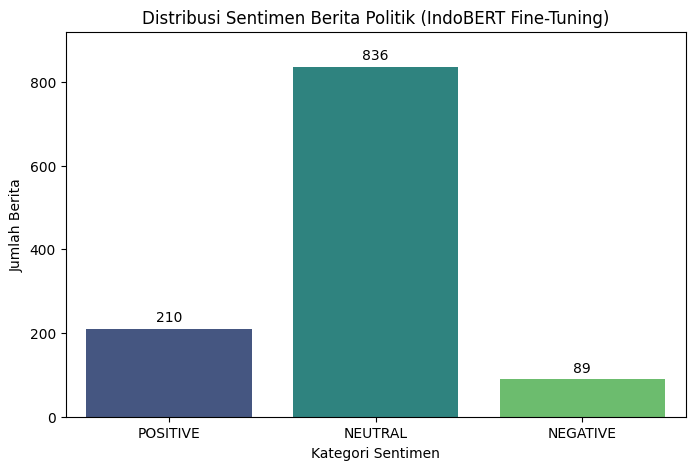

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualisasi Distribusi Sentimen dengan angka di atasnya
plt.figure(figsize=(8,5))

# Simpan plot ke variabel 'ax' supaya bisa kita ambil datanya buat label
ax = sns.countplot(x='sentimen', data=df, palette='viridis')

# INI KUNCINYA: Tambahin angka di atas setiap bar
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Distribusi Sentimen Berita Politik (IndoBERT Fine-Tuning)')
plt.ylabel('Jumlah Berita')
plt.xlabel('Kategori Sentimen')

# Biar angka di atas nggak kepotong kalau barnya tinggi banget
plt.ylim(0, df['sentimen'].value_counts().max() * 1.1)

plt.show()

In [ ]:
# 4. Cek hasil
print("\nHasil Labeling:")
print(df['sentimen'].value_counts())


Hasil Labeling:
sentimen
NEUTRAL     836
POSITIVE    210
NEGATIVE     89
Name: count, dtype: int64


In [ ]:
# Simpan hasil gabungan kembali ke Drive agar tidak hilang saat session Colab habis
df.to_csv(path_folder + "hasil_labeling_IndoBERT.csv", index=False)